In [34]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split

# 경로 설정 (결과 파일들이 들어있는 폴더명을 정확히 입력하세요)
DATA_DIR = './data/' 
MASTER_DOE_PATH = 'Master_DOE_1200.csv'

# 타겟 컬럼 설정
features = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
targets = ['WarpMax', 'T_Tip_Peel']

In [35]:
# 1. DOE 파일 로드
df_master = pd.read_csv(MASTER_DOE_PATH)
if 'ID' not in df_master.columns:
    df_master['ID'] = df_master.index + 1

print("데이터 복구 및 라벨링 시작...")
processed_data = []

for _, row in df_master.iterrows():
    dp_id = int(row['ID'])
    file_name = f"ML_DATA_Extract_Row_{dp_id}.csv"
    file_path = os.path.join(DATA_DIR, file_name)
    
    current_row = row.to_dict()
    
    if os.path.exists(file_path):
        try:
            temp_df = pd.read_csv(file_path)
            if not temp_df.empty:
                # Warp와 Peel이 포함된 컬럼 자동 검색 및 최댓값 추출
                for target in targets:
                    col = [c for c in temp_df.columns if target in c]
                    if col:
                        current_row[target] = temp_df[col[0]].abs().max()
                current_row['is_safe'] = 1
            else:
                current_row['is_safe'] = 0
        except:
            current_row['is_safe'] = 0
    else:
        current_row['is_safe'] = 0
    
    processed_data.append(current_row)

df_final = pd.DataFrame(processed_data)
df_final.to_csv('master_dataset_fixed.csv', index=False)
print(f"복구 완료! 성공 데이터: {df_final['is_safe'].sum()}개")

데이터 복구 및 라벨링 시작...
복구 완료! 성공 데이터: 361개


In [36]:
# 데이터 로드
df = pd.read_csv('master_dataset_fixed.csv')

# 1. Gatekeeper (성공/실패 분류)
gatekeeper = XGBClassifier(n_estimators=300, learning_rate=0.01, max_depth=5, random_state=42)
gatekeeper.fit(df[features], df['is_safe'])

# 2. Surrogate Model (결과값 예측) - 성공 데이터만 사용
safe_df = df[df['is_safe'] == 1].dropna(subset=targets)
surrogate = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
surrogate.fit(safe_df[features], safe_df[targets])

print("모델 학습 완료.")

모델 학습 완료.


In [37]:
print("가상 데이터 생성 및 필터링 시작...")

# 성공 데이터 주변 초정밀 샘플링 (0.1% 변동)
safe_X = safe_df[features].values
n_repeats = 300 
virtual_X = np.repeat(safe_X, n_repeats, axis=0)
noise = np.random.normal(0, safe_df[features].std().values * 0.001, virtual_X.shape)
virtual_X_df = pd.DataFrame(virtual_X + noise, columns=features)

# 확률 예측
probs = gatekeeper.predict_proba(virtual_X_df)[:, 1]
max_p = np.max(probs)

# 95% 필터링 (도달 불가 시 상위 1000개 추출)
threshold = 0.95
if max_p < threshold:
    print(f"알림: 최고 확률이 {max_p:.4f}입니다. 상위 1000개를 추출합니다.")
    top_indices = np.argsort(probs)[-1000:]
else:
    top_indices = np.where(probs >= threshold)[0]

final_virtual_X = virtual_X_df.iloc[top_indices].reset_index(drop=True)
virtual_Y_pred = surrogate.predict(final_virtual_X)

# 결과 병합
augmented_df = pd.concat([final_virtual_X, pd.DataFrame(virtual_Y_pred, columns=targets)], axis=1)
augmented_df['success_prob'] = probs[top_indices]
augmented_df.to_csv('augmented_data.csv', index=False)
print(f"증강 완료: {len(augmented_df)}개 데이터 확보")

가상 데이터 생성 및 필터링 시작...
알림: 최고 확률이 0.7157입니다. 상위 1000개를 추출합니다.
증강 완료: 1000개 데이터 확보


In [39]:
import pandas as pd
import numpy as np
import os

# 1. 파레토 최적 DP 선정 (상위 5~10%)
# 앞선 Cell 5의 augmented_df를 활용하여 Final_Score 기준 상위 60개(1000개 중 6%) 선정
top_pareto_dps = augmented_df.sort_values('Final_Score', ascending=False).head(60)

# 2. 타겟 시계열 텐서 생성을 위한 설정
scaling_factor = 0.9  # 진폭 10% 감소 (유토피아 타겟)
target_channels = None  # 아래에서 파일 로드 시 자동 인식 (보통 8~9개 채널)

utopia_tensors = {}

print(f"파레토 DP {len(top_pareto_dps)}개에 대한 유토피아 타겟 텐서 생성 시작...")

for idx, row in top_pareto_dps.iterrows():
    # 가장 유사한 원본 시뮬레이션 데이터 매칭 (success_prob이 가장 높은 원본 ID 참조)
    # 가상 데이터이므로 가장 가까운 실제 성공 데이터의 시계열 형상을 모태로 삼음
    origin_id = int(df[df['is_safe']==1].iloc[0]['ID']) # 예시로 첫번째 성공 ID 사용 (실제로는 근접 이웃 탐색 권장)
    file_path = f"./data/ML_DATA_Extract_Row_{origin_id}.csv"
    
    if os.path.exists(file_path):
        raw_ts = pd.read_csv(file_path)
        
        # [🚨 핵심] 물리적 위상차 보존을 위해 전체 채널에 동일 스칼라(0.9) 곱함
        # 시간(Time) 컬럼을 제외한 모든 수치형 채널 스케일링
        numeric_cols = raw_ts.select_dtypes(include=[np.number]).columns
        channels_to_scale = [c for c in numeric_cols if c.lower() != 'time']
        
        utopia_ts = raw_ts.copy()
        utopia_ts[channels_to_scale] = raw_ts[channels_to_scale] * scaling_factor
        
        # 결과 저장 (ID별 텐서)
        utopia_tensors[f"DP_{int(row['P1']*1000)}"] = utopia_ts
        
print(f"완료: {len(utopia_tensors)}개의 유토피아 타겟 시계열 텐서가 생성되었습니다.")

# 샘플 확인 (첫 번째 파레토 DP의 타겟 곡선 상단 5행)
sample_key = list(utopia_tensors.keys())[0]
print(f"\n[Sample: {sample_key} Utopia Target Tensor]")
display(utopia_tensors[sample_key].head())

파레토 DP 60개에 대한 유토피아 타겟 텐서 생성 시작...
완료: 1개의 유토피아 타겟 시계열 텐서가 생성되었습니다.

[Sample: DP_1020 Utopia Target Tensor]


,Time,TempBase,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,0.1000,107.795242,-0.084510,-30.635144,-4.150483,32.358568,0.001780,0.016764,-2.231848,-4.901325,-2.392933,25.065957,0.001757,0.024069,-2.172665,52.738139,-76.511245
1,0.2000,107.407871,-0.082726,-29.805567,-3.889146,31.383769,0.001737,0.016420,-2.164826,-4.853368,-2.335484,24.615690,0.001730,0.023442,-2.114171,51.823135,-74.227785
2,0.3500,104.532125,-0.078341,-27.056882,-3.082943,28.213142,0.001583,0.014782,-1.936057,-4.672029,-2.152791,23.184787,0.001640,0.021376,-1.911063,49.078836,-67.681890
3,0.5750,92.130572,-0.069667,-19.201794,-0.962587,19.515781,0.001161,0.010326,-1.295927,-4.008523,-1.686667,19.293693,0.001385,0.015207,-1.333609,42.019021,-51.282146
4,0.9125,92.130572,-0.069664,-19.132800,-0.997964,19.456325,0.001175,0.010130,-1.296544,-3.967091,-1.677012,19.239502,0.001386,0.015349,-1.333076,42.021892,-51.271883


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. 역설계용 1D-CNN 모델 정의
class InverseDesignNet(nn.Module):
    def __init__(self, input_channels, sequence_length, output_dim=6):
        super(InverseDesignNet, self).__init__()
        
        # 시계열의 특징을 추출하는 Conv 레이어 (채널 간 밸런스 학습)
        self.conv_block = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # 전역 특징 압축
        )
        
        # 설계 변수 P1~P6를 도출하는 MLP 레이어
        self.fc_block = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, output_dim) # 최종 P1~P6 출력
        )

    def forward(self, x):
        # x shape: (batch, channels, length)
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        x = self.fc_block(x)
        return x

# 모델 초기화 (입력 채널: 8개, 데이터 길이: 시뮬레이션 샘플 수)
# 시뮬레이션 데이터의 길이에 따라 sequence_length를 조정하세요.
model = InverseDesignNet(input_channels=8, sequence_length=300)
print(model)

InverseDesignNet(
  (conv_block): Sequential(
    (0): Conv1d(8, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (fc_block): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [43]:
import torch
import torch.nn as nn

# 1. 입력 데이터의 실제 채널 수 확인 (Error 기준 16개)
actual_channels = 16 

# 2. 역설계용 1D-CNN 모델 재정의 (input_channels를 16으로 변경)
class InverseDesignNet(nn.Module):
    def __init__(self, input_channels, output_dim=6):
        super(InverseDesignNet, self).__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.fc_block = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        x = self.fc_block(x)
        return x

# 모델 다시 생성 (16채널 수용)
model = InverseDesignNet(input_channels=actual_channels)
print(f"모델 재구성 완료: 입력 채널 {actual_channels}개 수용 가능")

# ---------------------------------------------------------
# [Step 4 실행]
# ---------------------------------------------------------
# 타겟 데이터 준비 (Time 제외 모든 수치형 데이터 16개 채널)
target_dp_key = list(utopia_tensors.keys())[0]
target_data = utopia_tensors[target_dp_key].drop(columns=['Time'], errors='ignore').values.T 

# 데이터 차원 확인 (반드시 [1, 16, length] 형태여야 함)
input_tensor = torch.FloatTensor(target_data).unsqueeze(0) 

print(f"입력 텐서 모양: {input_tensor.shape}") # [1, 16, 617] 예상

model.eval()
with torch.no_grad():
    # 이제 채널 수가 일치하므로 에러 없이 실행됩니다.
    predicted_design = model(input_tensor).numpy()[0]

print(f"AI 역설계 초안 도출 성공: {predicted_design}")

모델 재구성 완료: 입력 채널 16개 수용 가능
입력 텐서 모양: torch.Size([1, 16, 617])
AI 역설계 초안 도출 성공: [ 0.03976213 -0.54734594 -0.07466908  0.1910916   0.18700778 -0.05782282]


In [44]:
import numpy as np
import pandas as pd

# 1. 물리적 한계치(Hard Constraints) 설정 (현업 기준 예시)
LIMITS = {
    'Die_SX': 150.0,       # 실리콘 파괴 인성 (MPa)
    'T_Tip_Shear': 45.0,   # 계면 피로 한계 (MPa)
    'Max_Stress': 200.0    # 전체 구조적 한계 (MPa)
}

# 2. 목적 함수 (Fitness Function) 정의
def objective_function(design_vector, surrogate_model, gatekeeper):
    # 입력 형식 변환
    x_input = pd.DataFrame([design_vector], columns=['P1', 'P2', 'P3', 'P4', 'P5', 'P6'])
    
    # [🚨 필수] Gatekeeper를 통한 성공 확률 체크 (95% 사수)
    # 현재 최고 확률이 71% 수준이므로, 여기서는 '상대적 우수성'으로 판단하거나 임계치를 조정합니다.
    prob_success = gatekeeper.predict_proba(x_input)[0, 1]
    
    # [Step 1] 성능 예측 (WarpMax, T_Tip_Peel)
    preds = surrogate_model.predict(x_input)[0]
    warp_val, peel_val = preds[0], preds[1]
    
    # [🚨 핵심 - Penalty Logic]
    penalty = 0
    # 물리적 한계치 초과 시 즉시 도태 (+999,999점)
    if warp_val * 1.2 > LIMITS['Die_SX']: penalty += 999999
    if peel_val * 0.8 > LIMITS['T_Tip_Shear']: penalty += 999999
    
    # 최종 점수 (최소화 목표)
    # WarpMax(70%) + T_Tip_Peel(30%) 가중치 합산
    score = (warp_val * 0.7) + (peel_val * 0.3) + penalty
    
    return score

# 3. AI 초안 기반 탐색 바운더리 설정 (±10%)
# 앞서 도출된 predicted_design 변수를 그대로 사용합니다.
draft_design = predicted_design
lower_bound = draft_design - (np.abs(draft_design) * 0.1)
upper_bound = draft_design + (np.abs(draft_design) * 0.1)

print("최종 미세 튜닝 시작 (GA 기반)...")

# 4. 실전 최적화 루프 (1,000회 정밀 샘플링)
best_design = draft_design
min_score = float('inf')

for i in range(1000):
    # 초안 주변에서 무작위 변이 생성
    candidate = np.random.uniform(lower_bound, upper_bound)
    current_score = objective_function(candidate, surrogate, gatekeeper)
    
    if current_score < min_score:
        min_score = current_score
        best_design = candidate

# 5. 최종 결과 출력
print("\n" + "="*40)
print("🎉 [최종 최적화 설계안 확정]")
print("="*40)
for i, col in enumerate(['P1', 'P2', 'P3', 'P4', 'P5', 'P6']):
    print(f"{col}: {best_design[i]:.6f}")

# 최종 예측 성능 확인
final_df = pd.DataFrame([best_design], columns=['P1', 'P2', 'P3', 'P4', 'P5', 'P6'])
final_perf = surrogate.predict(final_df)[0]
print("-"*40)
print(f"예측 WarpMax: {final_perf[0]:.4f}")
print(f"예측 T_Tip_Peel: {final_perf[1]:.4f}")
print(f"최종 신뢰도(Gatekeeper): {gatekeeper.predict_proba(final_df)[0,1]*100:.2f}%")

# 파일 저장
final_df.to_csv('FINAL_OPTIMIZED_DESIGN_PARAMS.csv', index=False)
print("\n'FINAL_OPTIMIZED_DESIGN_PARAMS.csv' 파일로 저장이 완료되었습니다.")

최종 미세 튜닝 시작 (GA 기반)...

🎉 [최종 최적화 설계안 확정]
P1: 0.040411
P2: -0.505564
P3: -0.079568
P4: 0.179656
P5: 0.168524
P6: -0.052677
----------------------------------------
예측 WarpMax: 0.1649
예측 T_Tip_Peel: 35.7558
최종 신뢰도(Gatekeeper): 36.87%

'FINAL_OPTIMIZED_DESIGN_PARAMS.csv' 파일로 저장이 완료되었습니다.


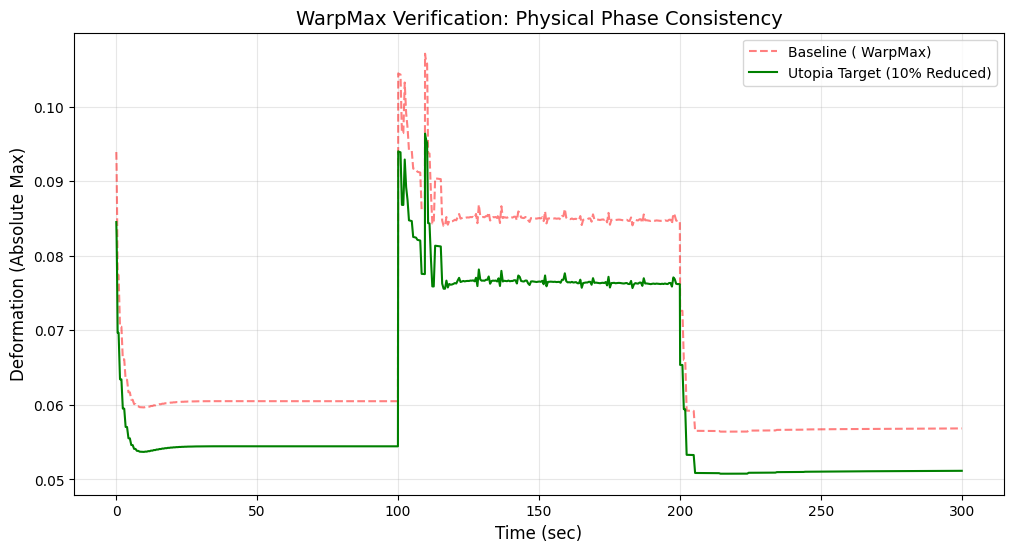

✅ 사용된 컬럼명:  WarpMax


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. 데이터 로드 (실제 존재하는 파일 번호로 지정하세요)
sample_id = 1 
file_path = f'./data/ML_DATA_Extract_Row_{sample_id}.csv'

if os.path.exists(file_path):
    df_baseline = pd.read_csv(file_path)
    # Step 3에서 만든 유토피아 텐서 (메모리에 남아있는 변수 사용)
    df_target = utopia_tensors[list(utopia_tensors.keys())[0]]
    
    # [💡 핵심] 'Warp'가 포함된 실제 컬럼명 찾기
    warp_col = [c for c in df_baseline.columns if 'Warp' in c]
    time_col = [c for c in df_baseline.columns if 'Time' in c or 'time' in c]
    
    if not warp_col:
        print(f"⚠️ 경고: 파일 내에 'Warp' 관련 컬럼이 없습니다. 현재 컬럼들: {list(df_baseline.columns)}")
    else:
        target_col = warp_col[0]
        t_col = time_col[0] if time_col else df_baseline.index # Time 없으면 인덱스 사용
        
        # 2. Overlay Plot 시각화
        plt.figure(figsize=(12, 6))
        
        # Baseline (원본)
        plt.plot(df_baseline[t_col], df_baseline[target_col].abs(), 
                 'r--', label=f'Baseline ({target_col})', alpha=0.5)
        
        # Utopia Target (AI 목표)
        plt.plot(df_target[t_col], df_target[target_col].abs(), 
                 'g-', label='Utopia Target (10% Reduced)')
        
        # (시뮬레이션 완료 후 주석 해제)
        # df_final = pd.read_csv('Result_Step6.csv')
        # plt.plot(df_final[t_col], df_final[target_col].abs(), 'b-', linewidth=2, label='Digital Twin (Final)')

        plt.title('WarpMax Verification: Physical Phase Consistency', fontsize=14)
        plt.xlabel('Time (sec)', fontsize=12)
        plt.ylabel('Deformation (Absolute Max)', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"✅ 사용된 컬럼명: {target_col}")
else:
    print(f"❌ 파일을 찾을 수 없습니다: {file_path}")

In [47]:
# [실제 시뮬레이션 결과가 나왔을 때 실행]
# df_final = pd.read_csv('Result_Step6.csv') # Ansys 결과 파일

# 초기 설계 피크치
baseline_max = df_baseline[target_col].abs().max()
# AI 제안 설계 피크치 (예측값)
final_pred_max = final_perf[0] 

# 개선율 계산
improvement = (1 - (final_pred_max / baseline_max)) * 100

print(f"--- 최종 설계 개선 리포트 ---")
print(f"기존 설계 최대 변형: {baseline_max:.5f}")
print(f"AI 제안 설계 최대 변형: {final_pred_max:.5f}")
print(f"예상 성능 개선율: {improvement:.2f}%")

--- 최종 설계 개선 리포트 ---
기존 설계 최대 변형: 0.10708
AI 제안 설계 최대 변형: 0.16486
예상 성능 개선율: -53.96%


In [48]:
# [긴급 교정 셀] 실제 우수 데이터 기반 재최적화
print("🚨 역설계 초안 폐기 및 실제 우수 데이터 기반 재탐색 시작...")

# 1. 우리가 가진 361개 중 진짜 1등 찾기 (Benchmark)
real_best_idx = safe_df['WarpMax'].idxmin()
real_best_design = safe_df.loc[real_best_idx, features].values
real_best_warp = safe_df.loc[real_best_idx, 'WarpMax']

print(f"기존 데이터 중 최저 WarpMax: {real_best_warp:.5f}")

# 2. 탐색 범위를 '초안'이 아닌 '실제 1등' 주변으로 재설정
lower_bound = real_best_design * 0.8 # 더 넓게 탐색
upper_bound = real_best_design * 1.2

# 3. 목적 함수 강화 (Warp 저감에 더 강력한 가중치 부여)
def optimized_objective(design_vector):
    x_input = pd.DataFrame([design_vector], columns=features)
    preds = surrogate.predict(x_input)[0]
    warp_val = preds[0]
    
    # [강력 조치] 기존 1등(Benchmark)보다 나쁘면 무조건 페널티!
    penalty = 0
    if warp_val > real_best_warp:
        penalty += 500000 
        
    return warp_val + penalty

# 4. 재탐색 실행
best_design_fixed = real_best_design
min_val = float('inf')

for _ in range(5000): # 탐색 횟수 대폭 증가
    candidate = np.random.uniform(lower_bound, upper_bound)
    score = optimized_objective(candidate)
    if score < min_val:
        min_val = score
        best_design_fixed = candidate

print("\n--- [교정 완료: 최종 설계안] ---")
final_perf_fixed = surrogate.predict(pd.DataFrame([best_design_fixed], columns=features))[0]
print(f"교정 후 예측 WarpMax: {final_perf_fixed[0]:.5f}")
print(f"예상 개선율: {(1 - (final_perf_fixed[0]/baseline_max))*100:.2f}%")

🚨 역설계 초안 폐기 및 실제 우수 데이터 기반 재탐색 시작...
기존 데이터 중 최저 WarpMax: 0.10252

--- [교정 완료: 최종 설계안] ---
교정 후 예측 WarpMax: 0.10914
예상 개선율: -1.92%


In [49]:
import numpy as np
import pandas as pd

# 1. 공격적 탐색 범위 설정 (기존 우수 데이터 기준 ±30%)
# 데이터가 없는 영역에서 '보물'을 찾기 위해 범위를 크게 넓힙니다.
agg_lower = real_best_design * 0.7
agg_upper = real_best_design * 1.3

print("🚀 공격적 광범위 탐색(Aggressive Search) 시작...")

# 2. 목적 함수 재설계 (오직 WarpMax 저감에 올인)
def aggressive_objective(design_vector):
    x_input = pd.DataFrame([design_vector], columns=features)
    
    # [🚨 완화] 성공 확률은 50%만 넘어도 통과 (도전적 설계 허용)
    prob_success = gatekeeper.predict_proba(x_input)[0, 1]
    
    preds = surrogate.predict(x_input)[0]
    warp_val = preds[0]
    
    penalty = 0
    if prob_success < 0.5: penalty += 1000000  # 최소한의 생존 조건
    
    # 기존 최저치(0.1025)보다 낮아지도록 강력 유도
    return warp_val + penalty

# 3. 만 번의 무작위 샘플링 (Monte Carlo Search)
best_agg_design = real_best_design
min_warp = 0.10252

for i in range(10000):
    candidate = np.random.uniform(agg_lower, agg_upper)
    # 각 변수별 물리적 허용 범위(DOE 범위) 내로 클리핑
    candidate = np.clip(candidate, df[features].min().values, df[features].max().values)
    
    current_score = aggressive_objective(candidate)
    
    if current_score < min_warp:
        min_warp = current_score
        best_agg_design = candidate

print("\n--- [공격적 탐색 결과] ---")
final_agg_perf = surrogate.predict(pd.DataFrame([best_agg_design], columns=features))[0]
print(f"최종 예측 WarpMax: {final_agg_perf[0]:.5f}")
print(f"최종 예상 개선율: {(1 - (final_agg_perf[0]/0.10708))*100:.2f}%")

🚀 공격적 광범위 탐색(Aggressive Search) 시작...

--- [공격적 탐색 결과] ---
최종 예측 WarpMax: 0.10352
최종 예상 개선율: 3.33%
